In [ ]:
# --- CELDA 1: Instalación y Configuración ---
# Instalar VizDoom y sus dependencias (necesario en Linux/Kaggle)
!sudo apt-get update
!sudo apt-get install -y cmake libboost-all-dev libsdl2-dev libopenal-dev zlib1g-dev libbz2-dev libjpeg-dev
!pip install vizdoom

# Clonar el repositorio para obtener los escenarios (defend_the_center.cfg y .wad)
!git clone https://github.com/mehdiboubnan/Deep-Reinforcement-Learning-applied-to-DOOM.git

# Verificar que los archivos están ahí
import os
scenario_path = 'Deep-Reinforcement-Learning-applied-to-DOOM/scenarios/defend_the_center.cfg'
if os.path.exists(scenario_path):
    print("✅ Archivos del escenario encontrados exitosamente.")
else:
    print("❌ Error: No se encontraron los archivos. Verifica la ruta.")

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,160 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,840 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,499 kB]
Hit:13 https://ppa.launchp

In [ ]:
# --- CELDA DE CORRECCIÓN: Buscador Automático de Archivos ---
import os

# Buscamos el archivo recursivamente para evitar errores de ruta manuales
search_dir = 'Deep-Reinforcement-Learning-applied-to-DOOM'
config_path = None

print(f"Buscando configuración en: {search_dir}...")

for root, dirs, files in os.walk(search_dir):
    for file in files:
        # Buscamos algo que suene a "defend" y termine en .cfg
        if 'defend' in file.lower() and file.endswith('.cfg'):
            config_path = os.path.join(root, file)
            print(f"✅ ¡ENCONTRADO! Usaremos esta ruta: {config_path}")
            break
    if config_path: break

if config_path is None:
    print("❌ Sigue sin encontrarse. Listando carpetas raíz:")
    print(os.listdir(search_dir))
else:
    print("La variable 'config_path' ha sido actualizada correctamente.")

Buscando configuración en: Deep-Reinforcement-Learning-applied-to-DOOM...
✅ ¡ENCONTRADO! Usaremos esta ruta: Deep-Reinforcement-Learning-applied-to-DOOM/A3C_Curiosity/scenarios/defend_the_center.cfg
La variable 'config_path' ha sido actualizada correctamente.


In [ ]:
# --- CELDA 2: Definición de la Clase DoomEnvironment (Actualizada) ---

import torch
import cv2
import numpy as np
from vizdoom import *
import random
from collections import deque
import matplotlib.pyplot as plt

class DoomEnvironment:
    def __init__(self, config_file_path):
        self.game = DoomGame()
        self.game.load_config(config_file_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.GRAY8)
        self.game.set_screen_resolution(ScreenResolution.RES_640X480)
        self.game.init()

        # Acciones para Defend the Center (Izquierda, Derecha, Disparar)
        self.actions = np.identity(3, dtype=int).tolist()
        print("Doom inicializado correctamente.")

    def preprocess(self, frame):
        # Resize a 84x84 y normalización
        frame = cv2.resize(frame, (84, 84), interpolation=cv2.INTER_AREA)
        frame = frame.astype(np.float32) / 255.0
        return frame

    def stack_frames(self, stacked_frames, state, is_new_episode):
        processed_frame = self.preprocess(state)
        if is_new_episode:
            stacked_frames = deque([processed_frame] * 4, maxlen=4)
        else:
            stacked_frames.append(processed_frame)

        state_tensor = np.stack(stacked_frames, axis=0)
        state_tensor = torch.from_numpy(state_tensor).float()
        return state_tensor, stacked_frames

    def step(self, action_index):
        reward = self.game.make_action(self.actions[action_index])
        done = self.game.is_episode_finished()
        if not done:
            state = self.game.get_state().screen_buffer
        else:
            state = np.zeros((84, 84))
        return state, reward, done

    def reset(self):
        self.game.new_episode()
        state = self.game.get_state().screen_buffer
        return state

    def close(self):
        self.game.close()

# Verificamos que ya tenemos la ruta
if 'config_path' not in locals() or config_path is None:
    print("⚠️ ¡ALERTA! Ejecuta primero la CELDA DE CORRECCIÓN de arriba.")
else:
    print(f"Usando configuración: {config_path}")

Usando configuración: Deep-Reinforcement-Learning-applied-to-DOOM/A3C_Curiosity/scenarios/defend_the_center.cfg


Doom inicializado correctamente.


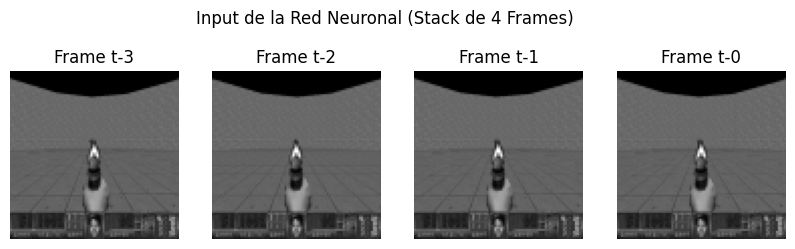

In [ ]:
# --- CELDA 3: Verificación Visual ---

# 1. Crear entorno
env = DoomEnvironment(config_path)

# 2. Iniciar variables de estado
stacked_frames = deque([np.zeros((84, 84), dtype=np.float32)] * 4, maxlen=4)
state = env.reset()

# 3. Procesar el primer estado (Stack inicial)
state_tensor, stacked_frames = env.stack_frames(stacked_frames, state, is_new_episode=True)

# 4. Dar unos pasos aleatorios
for _ in range(15):
    action = random.choice([0, 1, 2]) # Acción aleatoria
    next_state_img, reward, done = env.step(action)
    # Actualizar stack
    state_tensor, stacked_frames = env.stack_frames(stacked_frames, next_state_img, is_new_episode=False)

# 5. Visualizar lo que ve la red neuronal (los 4 frames apilados)
plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(state_tensor[i].numpy(), cmap='gray')
    plt.title(f"Frame t-{3-i}")
    plt.axis('off')

plt.suptitle("Input de la Red Neuronal (Stack de 4 Frames)")
plt.show()

env.close()

In [ ]:
# --- CÓDIGO FINAL: BIG BRAIN (SIN CASTIGOS) + FRAME SKIP ---

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import cv2
import imageio
import numpy as np
import random
from collections import deque
from vizdoom import *
from IPython.display import HTML, display, Video

# ==========================================
# 1. HIPERPARÁMETROS (ESTABLES)
# ==========================================
learning_rate = 0.0001     # Velocidad precisa para red grande
gamma = 0.99               # Visión a largo plazo estándar
buffer_limit = 20000       # Memoria amplia
batch_size = 64
max_episodes = 3500        # Tiempo suficiente para converger
epsilon = 1.0
epsilon_decay = 0.999      # Decaimiento lento para buena exploración
epsilon_min = 0.05         # Mínimo 5% de creatividad
target_update = 1000       # Estabilidad de red

video_filename = "doom_bigbrain_gameplay.mp4"
model_filename = "doom_bigbrain.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Iniciando BIG BRAIN (Modo Clásico) en: {device}")

# ==========================================
# 2. RED NEURONAL (DUELING DQN - 1024 NEURONAS)
# ==========================================
class DuelingDQN(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(DuelingDQN, self).__init__()

        # Convoluciones (Ojos)
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc_input_dim = 64 * 7 * 7

        # Corrientes (Cerebro Grande - 1024)
        self.value_stream = nn.Sequential(
            nn.Linear(self.fc_input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(self.fc_input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, num_actions)
        )

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.reshape(x.size(0), -1)

        val = self.value_stream(x)
        adv = self.advantage_stream(x)

        return val + (adv - adv.mean(dim=1, keepdim=True))

# ==========================================
# 3. ENTORNO (CON FRAME SKIP PERO SIN CASTIGO)
# ==========================================
class DoomEnvironmentClean:
    def __init__(self, config_file_path):
        self.game = DoomGame()
        self.game.load_config(config_file_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.GRAY8)
        self.game.set_screen_resolution(ScreenResolution.RES_640X480)
        self.game.init()
        self.actions = np.identity(3, dtype=int).tolist()

    def preprocess(self, frame):
        frame = cv2.resize(frame, (84, 84), interpolation=cv2.INTER_AREA)
        frame = frame.astype(np.float32) / 255.0
        return frame

    def stack_frames(self, stacked_frames, state, is_new_episode):
        processed = self.preprocess(state)
        if is_new_episode: stacked_frames = deque([processed]*4, maxlen=4)
        else: stacked_frames.append(processed)
        return torch.from_numpy(np.stack(stacked_frames, axis=0)).float(), stacked_frames

    def step(self, action_index):
        # MANTENEMOS EL FRAME SKIP (x4) PORQUE ES MUY BUENO
        reward = self.game.make_action(self.actions[action_index], 4)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state().screen_buffer
            # ¡AQUÍ ESTÁ EL CAMBIO!
            # Ya no restamos nada por daño. Solo cuenta los kills (+1)
        else:
            state = np.zeros((84, 84))

        return state, reward, done

    def reset(self):
        self.game.new_episode()
        return self.game.get_state().screen_buffer

    def close(self): self.game.close()

# Clases auxiliares
class ReplayBuffer:
    def __init__(self): self.buffer = deque(maxlen=buffer_limit)
    def put(self, transition): self.buffer.append(transition)
    def sample(self, n):
        batch = random.sample(self.buffer, n)
        s, a, r, sp, d = zip(*batch)
        return torch.stack(s), torch.tensor(a), torch.tensor(r), torch.stack(sp), torch.tensor(d)

# ==========================================
# 4. BUCLE DE ENTRENAMIENTO
# ==========================================
env = DoomEnvironmentClean(config_path)
net = DuelingDQN(input_shape=(4, 84, 84), num_actions=3).to(device)
target_net = DuelingDQN(input_shape=(4, 84, 84), num_actions=3).to(device)
target_net.load_state_dict(net.state_dict())

memory = ReplayBuffer()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scores = []

print(f"🚀 Iniciando ENTRENAMIENTO BIG BRAIN...")

step_count = 0
for n_epi in range(max_episodes):
    state = env.reset()
    frames = deque([np.zeros((84, 84), dtype=np.float32)]*4, maxlen=4)
    s, frames = env.stack_frames(frames, state, True)
    done = False
    score = 0.0

    while not done:
        step_count += 1
        # Epsilon Greedy
        if random.random() < epsilon: a = random.randint(0, 2)
        else: a = net(s.unsqueeze(0).to(device)).argmax().item()

        s_prime_img, r, done = env.step(a)
        sp, frames = env.stack_frames(frames, s_prime_img, False)

        memory.put((s, a, r, sp, 0.0 if done else 1.0))
        s = sp
        score += r

        # Entrenamiento
        if len(memory.buffer) >= batch_size:
            s_b, a_b, r_b, sp_b, d_b = memory.sample(batch_size)
            s_b, a_b, r_b, sp_b, d_b = s_b.to(device), a_b.unsqueeze(1).to(device), r_b.unsqueeze(1).float().to(device), sp_b.to(device), d_b.unsqueeze(1).float().to(device)

            q_val = net(s_b).gather(1, a_b)
            next_q = target_net(sp_b).max(1)[0].unsqueeze(1)
            target = r_b + gamma * next_q * d_b

            loss = F.smooth_l1_loss(q_val, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Actualización Red Objetivo
            if step_count % target_update == 0:
                target_net.load_state_dict(net.state_dict())

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    scores.append(score)

    if n_epi % 50 == 0:
        avg = sum(scores[-50:])/50
        print(f"Episodio {n_epi} | Score: {avg:.1f} | Epsilon: {epsilon:.2f}")

env.close()
torch.save(net.state_dict(), model_filename)

# ==========================================
# 5. GRABACIÓN DE CAMPEONATO
# ==========================================
print("\n🎥 Buscando partida Legendaria...")
env = DoomEnvironmentClean(config_path)
net.eval()
best = -999; best_f = []

for i in range(10):
    st = env.reset(); d = False; scr = 0; f_list = []
    frs = deque([np.zeros((84, 84), dtype=np.float32)]*4, maxlen=4)
    s, frs = env.stack_frames(frs, st, True)

    while not d:
        f_list.append(env.game.get_state().screen_buffer)
        with torch.no_grad(): a = net(s.unsqueeze(0).to(device)).argmax().item()
        n_st, r, d = env.step(a)
        s, frs = env.stack_frames(frs, n_st, False)
        scr += r

    print(f"   Intento {i+1}: {scr:.1f}")
    if scr > best: best = scr; best_f = f_list

env.close()

if len(best_f) > 0:
    print(f"\n🏆 ¡Récord Final! Guardando video con Score: {best:.1f}")
    imageio.mimsave(video_filename, best_f, fps=30)
    display(Video(video_filename, embed=True, html_attributes="controls loop autoplay"))
else:
    print("❌ Error: No se grabaron frames.")

🚀 Iniciando BIG BRAIN (Modo Clásico) en: cuda
🚀 Iniciando ENTRENAMIENTO BIG BRAIN...
Episodio 0 | Score: -0.0 | Epsilon: 1.00
Episodio 50 | Score: -0.1 | Epsilon: 0.95
Episodio 100 | Score: -0.2 | Epsilon: 0.90
Episodio 150 | Score: -0.1 | Epsilon: 0.86
Episodio 200 | Score: 0.2 | Epsilon: 0.82
Episodio 250 | Score: 0.3 | Epsilon: 0.78
Episodio 300 | Score: 0.2 | Epsilon: 0.74
Episodio 350 | Score: 0.2 | Epsilon: 0.70
Episodio 400 | Score: 0.3 | Epsilon: 0.67
Episodio 450 | Score: 0.5 | Epsilon: 0.64
Episodio 500 | Score: 0.6 | Epsilon: 0.61
Episodio 550 | Score: 1.4 | Epsilon: 0.58
Episodio 600 | Score: 1.1 | Epsilon: 0.55
Episodio 650 | Score: 1.0 | Epsilon: 0.52
Episodio 700 | Score: 1.9 | Epsilon: 0.50
Episodio 750 | Score: 2.3 | Epsilon: 0.47
Episodio 800 | Score: 2.1 | Epsilon: 0.45
Episodio 850 | Score: 2.5 | Epsilon: 0.43
Episodio 900 | Score: 2.1 | Epsilon: 0.41
Episodio 950 | Score: 3.1 | Epsilon: 0.39
Episodio 1000 | Score: 2.9 | Epsilon: 0.37
Episodio 1050 | Score: 2.7 | Ep